# 11 · Routing — *extra pattern*

**Idea:** A cheap classifier looks at the input and sends it to the **best specialist** (different prompt,
model, or tools). Saves money (easy questions → small model) and improves quality.

```
START -> classify --math----> math_expert
                  --code----> code_expert     -> END
                  --general-> general_chat
```
Here the **router is `qwen3:0.6b`** (fast, cheap) and specialists use `llama3.1`.

In [1]:
# --- Model setup -------------------------------------------------------------
# 1) Ollama must be running   ->  `ollama serve`  (the desktop app does this for you)
# 2) Pull the models once     ->  `ollama pull llama3.1`  and  `ollama pull qwen3:0.6b`
from langchain_ollama import ChatOllama

# llama3.1 (8B): our main "brain" - good at tool calling & structured output.
llm = ChatOllama(model="llama3.1", temperature=0)

# qwen3:0.6b: a tiny, very fast model - great for cheap jobs (classify, summarise, route).
# reasoning=False hides qwen3's <think> block so `.content` is just the answer.
small_llm = ChatOllama(model="qwen3:0.6b", temperature=0, reasoning=False)

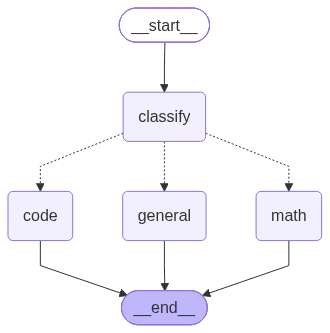

In [6]:
from typing import Literal, TypedDict
from langgraph.graph import StateGraph, START, END

Category = Literal["math", "code", "general"]

class State(TypedDict):
    question: str
    category: Category
    answer: str

def classify(state: State):
    raw = llm.invoke(
        "Classify the question into exactly one word: math, code, or general.\n"
        f"Question: {state['question']}\nAnswer with one word only."
    ).content.strip().lower()
    # Tiny models are sloppy: validate, and fall back to a safe default.
    print("Result:",raw)
    
    category = next((c for c in ("math", "code") if c in raw), "general")
    print(f"🧭 routed to: {category}  (raw model output: {raw!r})")
    return {"category": category}

def route(state: State) -> Category:
    return state["category"]                 # the conditional edge just returns the node name

def math_expert(state: State):
    return {"answer": llm.invoke(f"You are a careful math tutor. Show short steps.\n{state['question']}").content}

def code_expert(state: State):
    return {"answer": llm.invoke(f"You are a senior Python developer. Reply with a short code snippet.\n{state['question']}").content}

def general_chat(state: State):
    return {"answer": llm.invoke(f"Answer briefly and kindly.\n{state['question']}").content}

builder = StateGraph(State)
builder.add_node("classify", classify)
builder.add_node("math", math_expert)
builder.add_node("code", code_expert)
builder.add_node("general", general_chat)
builder.add_edge(START, "classify")
builder.add_conditional_edges("classify", route, ["math", "code", "general"])
for n in ("math", "code", "general"):
    builder.add_edge(n, END)
graph = builder.compile()

from IPython.display import display, Image

# Visualize the agent's decision-making flow
display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
for q in ["What is 15% of 240?", "Write a function to reverse a string", "Who painted the Mona Lisa?"]:
    print("\n❓", q)
    print("💬", graph.invoke({"question": q})["answer"][:300])


❓ What is 15% of 240?
Result: math
🧭 routed to: math  (raw model output: 'math')
💬 To find 15% of 240, I'll follow these steps:

1. Convert 15% to a decimal: 15% = 0.15
2. Multiply 0.15 by 240: 0.15 × 240 = 36

Answer: 15% of 240 is 36.

❓ Write a function to reverse a string
Result: code
🧭 routed to: code  (raw model output: 'code')
💬 **Reversing a String in Python**

Here's a concise and readable function to reverse a string in Python:

```python
def reverse_string(s: str) -> str:
    """Reverses the input string."""
    return s[::-1]
```

**Example Use Case:**
```python
print(reverse_string("he

❓ Who painted the Mona Lisa?
Result: general
🧭 routed to: general  (raw model output: 'general')
💬 Leonardo da Vinci painted the Mona Lisa.
